In [9]:
from pyspark.sql import SparkSession

# 1. Aseguramos la sesión activa en el Kernel actual
spark = SparkSession.builder.appName("Storytelling_Final").getOrCreate()

# 2. Traemos los datos nativos persistidos en formato Parquet
# Apuntamos a la carpeta real de datos etiquetados que tienes en tu directorio
ruta_datos_retail = "/home/jovyan/work/notebooks/modelos_output/datos_etiquetados_kmeans"

# Cargamos el DataFrame con los datos de tu clúster de Retail
df_completos = spark.read.parquet(ruta_datos_retail)
df_historico = spark.read.parquet(ruta_datos_retail)

# 3. Contamos cuántos registros totales logramos recuperar para el análisis
total_registros = df_historico.count()
print(f"ÉXITO: Conexión establecida. Hemos recuperado {total_registros} registros de retail del histórico.")

ÉXITO: Conexión establecida. Hemos recuperado 6174 registros de retail del histórico.


In [10]:
import pyspark.sql.functions as F

# 1. Calculamos el total de SKUs usando los datos etiquetados de retail alimenticio
total_sku = df_historico.count()

# 2. Agrupamos por marca para determinar su peso en la canasta básica
kpi_estrategico = df_historico.groupBy("marca") \
    .agg(
        F.count("marca").alias("Cantidad_SKUs"),
        F.round((F.count("marca") / total_sku) * 100, 2).alias("Participacion_Catalogo_Porcentaje")
    ).orderBy(F.desc("Cantidad_SKUs"))

# 3. Desplegamos el indicador clave de estructura de portafolio
print("=========================================================================")
print("[KPI ESTRATÉGICO] - ESTRUCTURA DE PORTAFOLIO DE MARCAS (RETAIL ALIMENTICIO)")
print("=========================================================================")

kpi_estrategico.show(20, truncate=False)

[KPI ESTRATÉGICO] - ESTRUCTURA DE PORTAFOLIO DE MARCAS (RETAIL ALIMENTICIO)
+--------------+-------------+---------------------------------+
|marca         |Cantidad_SKUs|Participacion_Catalogo_Porcentaje|
+--------------+-------------+---------------------------------+
|GENÉRICA      |1051         |17.02                            |
|LIDER         |298          |4.83                             |
|OTRA          |274          |4.44                             |
|Cuisine & Co  |274          |4.44                             |
|NUESTRA COCINA|172          |2.79                             |
|Soprole       |160          |2.59                             |
|GOURMET       |151          |2.45                             |
|Gourmet       |147          |2.38                             |
|COLUN         |125          |2.02                             |
|SOPROLE       |119          |1.93                             |
|Colun         |83           |1.34                             |
|MAGGI        

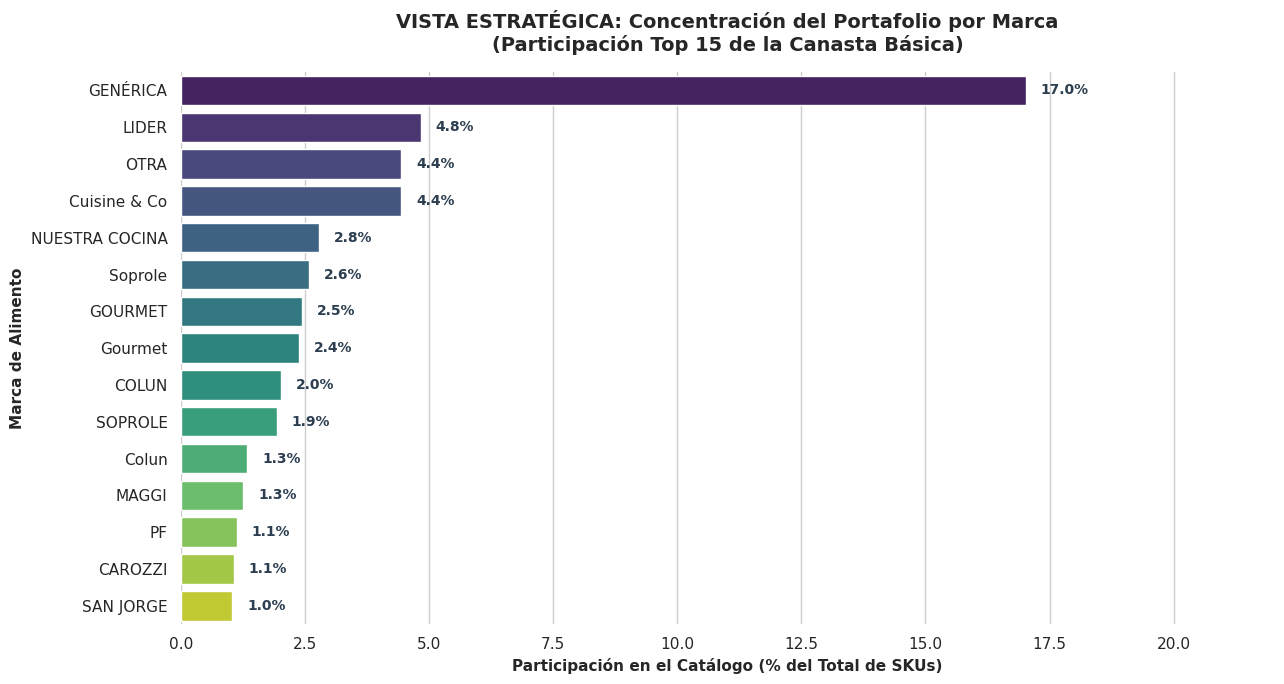

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F

# 1. Procesamiento en Spark
total_sku = df_historico.count()

kpi_estrategico = df_historico.groupBy("marca") \
    .agg(F.round((F.count("marca") / total_sku) * 100, 2).alias("Participacion_Porcentaje")) \
    .orderBy(F.desc("Participacion_Porcentaje"))

# 2. Conversión a Pandas solo para graficar (Tomamos las Top 15 marcas para evitar saturación)
df_est_pandas = kpi_estrategico.toPandas().head(15)

# 3. Diseño del Gráfico Estratégico
plt.figure(figsize=(13, 7))
sns.set_theme(style="whitegrid")

# Creamos gráfico de barras horizontales aplicando la corrección de Seaborn
ax = sns.barplot(
    x="Participacion_Porcentaje",
    y="marca",
    data=df_est_pandas,
    hue="marca",        # Corrección: Asignamos 'marca' a hue para mapear los colores de la paleta
    palette="viridis",  # Paleta moderna para reportes corporativos
    legend=False        # Corrección: Apagamos la leyenda automática que genera el parámetro hue
)

# Añadimos las etiquetas de porcentaje al final de cada barra de manera segura
for p in ax.patches:
    width = p.get_width()
    # Evitamos graficar etiquetas en barras vacías o errores de renderizado
    if width > 0:
        ax.annotate(
            f"{width:.1f}%",
            (width + 0.3, p.get_y() + p.get_height() / 2),
            va="center", 
            ha="left", 
            fontsize=10, 
            fontweight="bold",
            color="#2c3e50"
        )

# Títulos y personalización adaptada al Retail Alimenticio Chileno
plt.title(
    "VISTA ESTRATÉGICA: Concentración del Portafolio por Marca\n(Participación Top 15 de la Canasta Básica)", 
    fontsize=14, 
    fontweight="bold", 
    pad=15
)
plt.xlabel("Participación en el Catálogo (% del Total de SKUs)", fontsize=11, fontweight="bold")
plt.ylabel("Marca de Alimento", fontsize=11, fontweight="bold")

# Damos un margen dinámico a la derecha para que el texto del porcentaje no se corte
plt.xlim(0, df_est_pandas["Participacion_Porcentaje"].max() + 5)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [13]:
import pyspark.sql.functions as F

# 1. Analizamos la dispersión y bandas de precios reales para el Gerente Comercial
kpi_tactico = df_historico.groupBy("marca") \
    .agg(
        F.round(F.min("precio"), 2).alias("Precio_Minimo"),
        F.round(F.avg("precio"), 2).alias("Precio_Promedio"),
        F.round(F.max("precio"), 2).alias("Precio_Maximo"),
        F.round(F.stddev("precio"), 2).alias("Desviacion_Estandar_Precios")
    ).orderBy(F.desc("Desviacion_Estandar_Precios"))

# 2. Desplegamos el indicador táctico modificado para Retail Alimenticio
print("=========================================================================")
print("[KPI TÁCTICO] - MATRIZ DE VOLATILIDAD Y COMPETITIVIDAD DE PRECIOS (CLP)")
print("=========================================================================")

kpi_tactico.show(20, truncate=False)

[KPI TÁCTICO] - MATRIZ DE VOLATILIDAD Y COMPETITIVIDAD DE PRECIOS (CLP)
+--------------+-------------+---------------+-------------+---------------------------+
|marca         |Precio_Minimo|Precio_Promedio|Precio_Maximo|Desviacion_Estandar_Precios|
+--------------+-------------+---------------+-------------+---------------------------+
|Calan         |1590.0       |35804.44       |102000.0     |49660.35                   |
|Colun         |390.0        |15582.77       |82000.0      |24827.64                   |
|Nestle        |370.0        |13195.5        |81890.0      |22187.74                   |
|Quillayes     |2000.0       |12132.14       |63000.0      |21572.13                   |
|Surlat        |1190.0       |11653.33       |65100.0      |18360.42                   |
|Nuestra Cocina|440.0        |12250.77       |41000.0      |16598.75                   |
|VAN CAMPS     |1990.0       |12495.0        |23000.0      |14856.31                   |
|Loncoleche    |570.0        |8353.95 

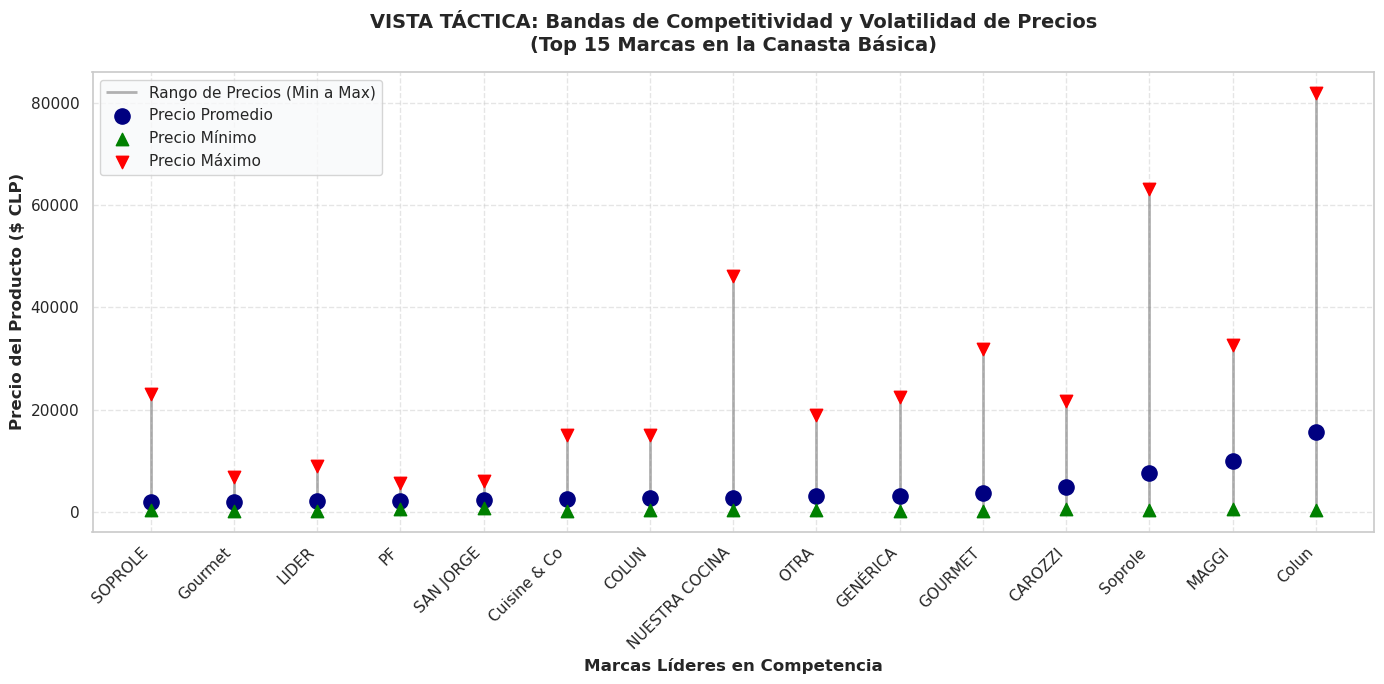

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F

# 1. Procesamiento en Spark: Calculamos estadísticas basándonos en las Top 15 marcas con más SKUs
# Primero identificamos cuáles son las marcas top para filtrar el gráfico y no saturarlo
marcas_top = [row['marca'] for row in df_historico.groupBy("marca").count().orderBy(F.desc("count")).take(15)]

kpi_tactico = df_historico.filter(df_historico.marca.isin(marcas_top)) \
    .groupBy("marca") \
    .agg(
        F.round(F.min("precio"), 2).alias("Precio_Minimo"),
        F.round(F.avg("precio"), 2).alias("Precio_Promedio"),
        F.round(F.max("precio"), 2).alias("Precio_Maximo")
    ).orderBy("Precio_Promedio")

# 2. Conversión a Pandas para visualización
df_tac_pandas = kpi_tactico.toPandas()

# 3. Diseño del Gráfico Táctico de Bandas de Precio
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Dibujamos las líneas de rango mínimo y máximo, y los puntos clave
plt.vlines(
    x=df_tac_pandas['marca'], 
    ymin=df_tac_pandas['Precio_Minimo'], 
    ymax=df_tac_pandas['Precio_Maximo'], 
    colors='gray', 
    alpha=0.6, 
    linewidth=2, 
    label="Rango de Precios (Min a Max)"
)

plt.scatter(df_tac_pandas['marca'], df_tac_pandas['Precio_Promedio'], color='navy', s=120, label="Precio Promedio", zorder=3)
plt.scatter(df_tac_pandas['marca'], df_tac_pandas['Precio_Minimo'], color='green', marker='^', s=80, label="Precio Mínimo", zorder=3)
plt.scatter(df_tac_pandas['marca'], df_tac_pandas['Precio_Maximo'], color='red', marker='v', s=80, label="Precio Máximo", zorder=3)

# Títulos y etiquetas adaptadas al contexto de Supermercados Chilenos
plt.title("VISTA TÁCTICA: Bandas de Competitividad y Volatilidad de Precios\n(Top 15 Marcas en la Canasta Básica)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Marcas Líderes en Competencia", fontsize=12, fontweight='bold')
plt.ylabel("Precio del Producto ($ CLP)", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.legend(loc="upper left", frameon=True, facecolor='#f8f9fa')
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [17]:
import pyspark.sql.functions as F

# 1. Alertas operacionales para el Supervisor:
# Filtramos productos con desvíos extremos en su categoría (ej: más de 50% sobre el promedio o menos de -50%)
umbral_desvio_operacional = 50.0

kpi_operacional_alertas = df_historico.filter(
    (F.col("dif_porcentual_promedio") >= umbral_desvio_operacional) | 
    (F.col("dif_porcentual_promedio") <= -50.0)
).select(
    "nombre_producto",          # Corregido: Cambiado 'nombre' por 'nombre_producto'
    "marca", 
    "supermercado",             # Añadido de tus datos reales para darle más contexto al supervisor
    "precio", 
    "precio_promedio_cat", 
    "dif_porcentual_promedio"
).orderBy(F.desc(F.abs(F.col("dif_porcentual_promedio"))))

# 2. Conteo de alertas detectadas para el reporte
total_alertas = kpi_operacional_alertas.count()

# 3. Despliegue formal del KPI Operacional
print("=========================================================================")
print(f"[KPI OPERACIONAL] - ALERTAS CRÍTICAS DE DISTORSIÓN DE PRECIOS EN GÓNDOLA")
print(f"Foco: Variaciones mayores al +/-{umbral_desvio_operacional}% respecto al promedio de su categoría")
print(f"Total de Alertas Detectadas: {total_alertas}")
print("=========================================================================")

# Mostramos las primeras 15 alertas que el supervisor debe auditar en tienda
kpi_operacional_alertas.show(15, truncate=False)

[KPI OPERACIONAL] - ALERTAS CRÍTICAS DE DISTORSIÓN DE PRECIOS EN GÓNDOLA
Foco: Variaciones mayores al +/-50.0% respecto al promedio de su categoría
Total de Alertas Detectadas: 3223
+----------------------------------------------------+--------------+------------+--------+-------------------+-----------------------+
|nombre_producto                                     |marca         |supermercado|precio  |precio_promedio_cat|dif_porcentual_promedio|
+----------------------------------------------------+--------------+------------+--------+-------------------+-----------------------+
|Pack 12 un. Crema de Leche Colun Sin Tapa 1 L       |Colun         |Santa Isabel|71880.0 |3695.8256532066507 |1844.9                 |
|Aceite de oliva nuestra cocina extra virgen 5 l     |NUESTRA COCINA|Unimarc     |46150.0 |3695.8256532066507 |1148.71                |
|Salsa de tomate lucchetti mamma mía napolitana 200 g|LUCCHETTI     |Unimarc     |43000.0 |3695.8256532066507 |1063.47                |
|Y

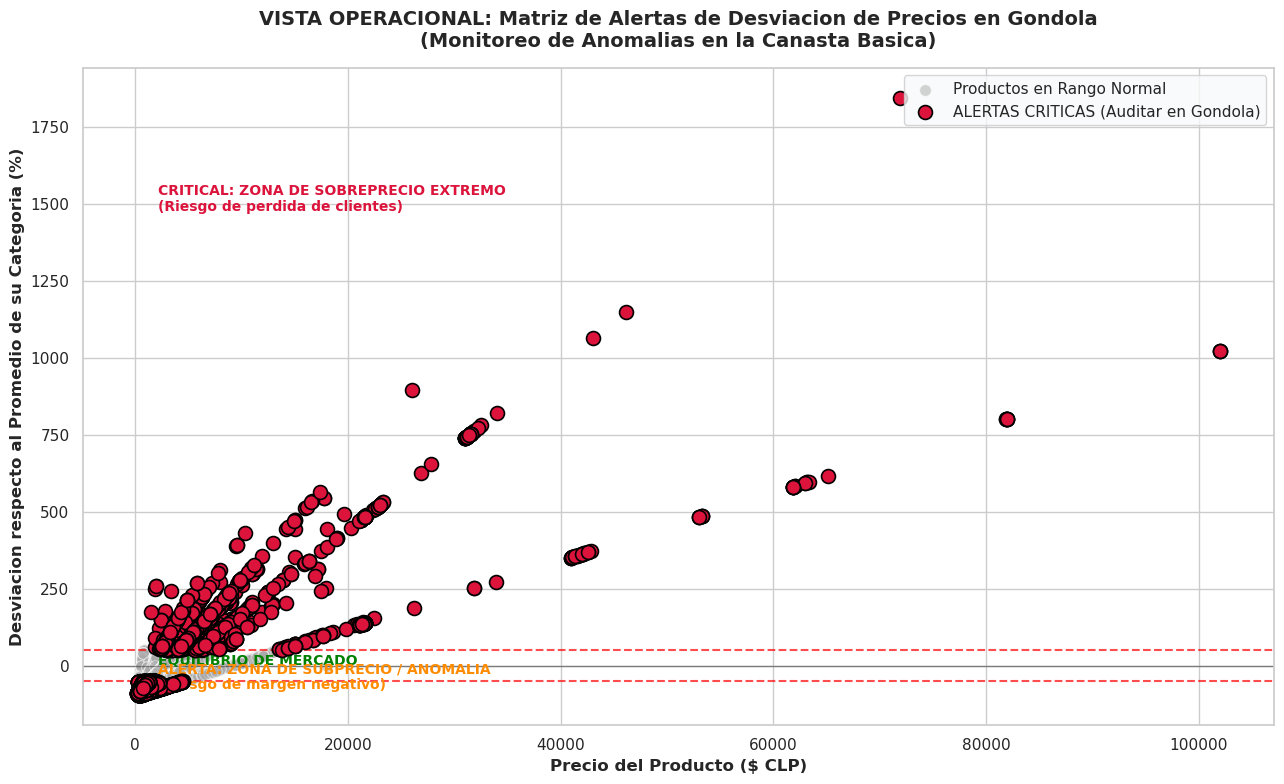

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F

# 1. Procesamiento en Spark: Seleccionamos las columnas reales del histórico de retail
kpi_operacional_completo = df_historico.select(
    "nombre_producto", 
    "marca", 
    "precio", 
    "dif_porcentual_promedio"
)
# Pasamos los datos filtrados a Pandas solo para el renderizado del gráfico
df_op_pandas = kpi_operacional_completo.toPandas()

# 2. Diseño del Gráfico Operacional
plt.figure(figsize=(13, 8))
sns.set_theme(style="whitegrid")

# Graficamos el grueso de los productos (Puntos base en gris)
sns.scatterplot(
    x="precio",
    y="dif_porcentual_promedio",
    data=df_op_pandas,
    alpha=0.5,
    s=70,
    color="darkgray",
    label="Productos en Rango Normal"
)

# Resaltamos en ROJO las alertas críticas (Variaciones mayores al +/- 50%)
umbral = 50.0
zona_peligro = df_op_pandas[(df_op_pandas['dif_porcentual_promedio'] >= umbral) | 
                            (df_op_pandas['dif_porcentual_promedio'] <= -umbral)]

sns.scatterplot(
    x="precio",
    y="dif_porcentual_promedio",
    data=zona_peligro,
    color="crimson",
    s=100,
    label="ALERTAS CRITICAS (Auditar en Gondola)",
    edgecolor="black",
    linewidth=1.2,
    zorder=5
)

# Dibujamos las líneas de umbral crítico operacional
plt.axhline(y=umbral, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
plt.axhline(y=-umbral, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.4, linewidth=1) # Línea de equilibrio

# Corrección: Quitamos los emojis de las etiquetas flotantes de texto para evitar el error del Font
y_max = df_op_pandas['dif_porcentual_promedio'].max()
y_min = df_op_pandas['dif_porcentual_promedio'].min()
x_medio = df_op_pandas['precio'].median()

plt.text(x_medio, y_max * 0.8, "CRITICAL: ZONA DE SOBREPRECIO EXTREMO\n(Riesgo de perdida de clientes)", color="crimson", weight="bold", fontsize=10)
plt.text(x_medio, 2, "EQUILIBRIO DE MERCADO", color="green", weight="bold", fontsize=10)
plt.text(x_medio, y_min * 0.8, "ALERTA: ZONA DE SUBPRECIO / ANOMALIA\n(Riesgo de margen negativo)", color="darkorange", weight="bold", fontsize=10)

# Títulos y personalización adaptada al Retail Chileno sin caracteres especiales conflictivos
plt.title("VISTA OPERACIONAL: Matriz de Alertas de Desviacion de Precios en Gondola\n(Monitoreo de Anomalias en la Canasta Basica)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Precio del Producto ($ CLP)", fontsize=12, fontweight='bold')
plt.ylabel("Desviacion respecto al Promedio de su Categoria (%)", fontsize=12, fontweight='bold')

plt.legend(loc="upper right", frameon=True, facecolor='#f8f9fa')
plt.tight_layout()
plt.show()

In [22]:
# 1. Seleccionamos las columnas clave del modelo de retail alimenticio para el Dashboard
columnas_dashboard = [
    "nombre_producto", "marca", "supermercado", "categoria", 
    "precio", "precio_promedio_cat", "dif_porcentual_promedio", "prediction"
]

df_dashboard_spark = df_historico.select(columnas_dashboard)

# 2. CORRECCIÓN: Forzamos la ruta absoluta hacia la carpeta 'notebooks'
# Esto garantiza que se cree ahí sin importar en qué carpeta estés ejecutando este notebook
ruta_salida_csv = "/home/jovyan/work/notebooks/datos_retail_dashboard.csv"

# Convertimos a Pandas y exportamos
df_dashboard_spark.toPandas().to_csv(ruta_salida_csv, index=False)

print("=========================================================================")
print("✅ ¡ÉXITO: Datos de la Canasta Básica exportados en la ruta correcta!")
print(f"Archivo generado directamente en: '{ruta_salida_csv}'")
print("=========================================================================")

✅ ¡ÉXITO: Datos de la Canasta Básica exportados en la ruta correcta!
Archivo generado directamente en: '/home/jovyan/work/notebooks/datos_retail_dashboard.csv'
